In [1]:
# NumPy patch — run first
import numpy as np
for _n, _a in [('bool8',np.bool_),('int0',np.intp),('uint0',np.uintp),
               ('object0',np.object_),('str0',np.str_),('bytes0',np.bytes_)]:
    if not hasattr(np, _n): setattr(np, _n, _a)
print('NumPy:', np.__version__)

NumPy: 1.24.3


C:\Users\PESU-CIE\AppData\Local\Temp\ipykernel_6816\3884710454.py:5: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, _n): setattr(np, _n, _a)
C:\Users\PESU-CIE\AppData\Local\Temp\ipykernel_6816\3884710454.py:5: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  if not hasattr(np, _n): setattr(np, _n, _a)
C:\Users\PESU-CIE\AppData\Local\Temp\ipykernel_6816\3884710454.py:5: DeprecationWarning: `np.uint0` is a deprecated alias for `np.uintp`.  (Deprecated NumPy 1.24)
  if not hasattr(np, _n): setattr(np, _n, _a)
C:\Users\PESU-CIE\AppData\Local\Temp\ipykernel_6816\3884710454.py:5: DeprecationWarning: `np.object0` is a deprecated alias for ``np.object0` is a deprecated alias for `np.object_`. `object` can be used instead.  (Deprecated NumPy 1.24)`.  (Deprecated NumPy 1.24)
  if not hasattr(np, _n): setattr(np, _n, _a)
C:\Users\PESU-CIE\AppData\Local\Temp\ipykernel_6816\3884710454.py

In [2]:
import os, re, random, math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import (classification_report, confusion_matrix,
    balanced_accuracy_score, roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB5

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

TF: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
os.chdir(r"C:\Users\PESU-CIE\Desktop\adni")

BASE_PATH   = r"C:\Users\PESU-CIE\Desktop\adni\processed"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASSES     = ["AD", "CN", "MCI"]
NUM_CLASSES = 3
EPOCHS_P2   = 40
EPOCHS_P3   = 60

TRAIN_DIR = os.path.join(BASE_PATH, "train")
VAL_DIR   = os.path.join(BASE_PATH, "val")
TEST_DIR  = os.path.join(BASE_PATH, "test")
CKPT_P1   = './models/best_effnet_p1.h5'
CKPT_P2   = './models/best_effnet_p2.h5'
CKPT_P3   = './models/best_effnet_p3.h5'
os.makedirs('./models', exist_ok=True)

for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c))) for c in CLASSES}
    print(f"{split}: {counts}")

train: {'AD': 9360, 'CN': 12240, 'MCI': 19920}
val: {'AD': 2220, 'CN': 2940, 'MCI': 4680}
test: {'AD': 2280, 'CN': 2940, 'MCI': 4620}


In [4]:
# Class weights
train_labels = []
for idx, cls in enumerate(CLASSES):
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    train_labels.extend([idx] * n)
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=np.array(train_labels))
class_weight_dict = {int(i): float(cw[i]) for i in range(3)}
print("Class weights:", {CLASSES[i]: round(class_weight_dict[i],3) for i in range(3)})

Class weights: {'AD': 1.479, 'CN': 1.131, 'MCI': 0.695}


In [5]:
# tf.data pipeline — GPU-friendly, no ImageDataGenerator bottleneck
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(directory, augment=False, shuffle=True):
    paths, labels = [], []
    for cls_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(directory, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_dir, f))
                lbl = np.zeros(NUM_CLASSES, dtype=np.float32)
                lbl[cls_idx] = 1.0
                labels.append(lbl)

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        img = tf.keras.applications.efficientnet.preprocess_input(img)
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, 0.2)
            img = tf.image.random_contrast(img, 0.8, 1.2)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices(
            (tf.constant(paths), tf.constant(labels)))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    # also return integer labels in file order for evaluation
    int_labels = np.array([np.argmax(l) for l in labels])
    return ds, len(paths), int_labels

train_ds, n_train, _           = make_dataset(TRAIN_DIR, augment=True,  shuffle=True)
val_ds,   n_val,   _           = make_dataset(VAL_DIR,   augment=False, shuffle=False)
test_ds,  n_test,  y_true_test = make_dataset(TEST_DIR,  augment=False, shuffle=False)

steps_per_epoch = math.ceil(n_train / BATCH_SIZE)
print(f"Train:{n_train}  Val:{n_val}  Test:{n_test}  Steps/epoch:{steps_per_epoch}")

Train:41520  Val:9840  Test:9840  Steps/epoch:1298


In [6]:
# Custom layers
class FocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, label_smoothing=0.01, **kwargs):
        super().__init__(**kwargs)
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)
    def call(self, y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        n      = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true = y_true*(1-self.label_smoothing) + self.label_smoothing/n
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce     = -y_true * tf.math.log(y_pred)
        pt     = tf.reduce_sum(y_true*y_pred, axis=-1, keepdims=True)
        return tf.reduce_mean(tf.reduce_sum(tf.pow(1-pt, self.gamma)*ce, axis=-1))
    def get_config(self):
        c = super().get_config()
        c.update({'gamma':self.gamma, 'label_smoothing':self.label_smoothing})
        return c

class GeMPooling(layers.Layer):
    def __init__(self, p_init=3.0, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.p_init = float(p_init); self.eps = float(eps)
    def build(self, input_shape):
        self.p = self.add_weight(
            name='p', shape=(1,), dtype=tf.float32,
            initializer=tf.constant_initializer(self.p_init), trainable=True,
            constraint=keras.constraints.MinMaxNorm(min_value=1.0, max_value=6.0))
        super().build(input_shape)
    def call(self, x):
        x   = tf.cast(x, tf.float32)
        p   = tf.cast(self.p, tf.float32)
        eps = tf.constant(self.eps, tf.float32)
        x   = tf.clip_by_value(x, eps, tf.reduce_max(x)+eps)
        return tf.pow(tf.reduce_mean(tf.pow(x, p), axis=[1,2]), 1.0/p)
    def get_config(self):
        c = super().get_config()
        c.update({'p_init':self.p_init, 'eps':self.eps}); return c

class StochasticDepth(layers.Layer):
    def __init__(self, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs); self.drop_rate = float(drop_rate)
    def call(self, x, training=None):
        if training and self.drop_rate > 0:
            keep  = 1.0 - self.drop_rate
            shape = (tf.shape(x)[0],) + (1,)*(len(x.shape)-1)
            return x * tf.floor(tf.random.uniform(shape)+keep) / keep
        return x
    def get_config(self):
        c = super().get_config(); c.update({'drop_rate':self.drop_rate}); return c

loss_fn = FocalLoss(gamma=2.0, label_smoothing=0.01)
print('Layers ready.')

Layers ready.


In [7]:
# Build model
def build_model():
    base = EfficientNetB5(include_top=False, weights='imagenet',
                          input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x   = base(inp, training=False)

    # SPP head
    gem = GeMPooling(p_init=3.0, name='gem')(x)
    p4  = layers.GlobalAveragePooling2D()(layers.AveragePooling2D((2,2))(x))
    p2  = layers.GlobalAveragePooling2D()(layers.AveragePooling2D((4,4))(x))
    x   = layers.Concatenate()([gem, p4, p2])

    x   = layers.Dense(512, kernel_regularizer=regularizers.l2(5e-5))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('swish')(x)
    x   = layers.Dropout(0.35)(x)
    x   = StochasticDepth(0.10)(x)
    x   = layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('swish')(x)
    x   = layers.Dropout(0.25)(x)
    x   = StochasticDepth(0.05)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out), base

model, base_model = build_model()
print(f'Parameters: {model.count_params():,}')

Parameters: 31,794,939


In [8]:
# LR scheduler
class CosineAnnealingLR(callbacks.Callback):
    def __init__(self, lr_max, lr_min, total_epochs, warmup=2):
        super().__init__()
        self.lr_max=float(lr_max); self.lr_min=float(lr_min)
        self.total_epochs=int(total_epochs); self.warmup=int(warmup)
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            lr = self.lr_min + (self.lr_max-self.lr_min)*epoch/max(self.warmup,1)
        else:
            prog = (epoch-self.warmup)/max(self.total_epochs-self.warmup,1)
            lr   = self.lr_min + 0.5*(self.lr_max-self.lr_min)*(1+math.cos(math.pi*prog))
        keras.backend.set_value(self.model.optimizer.learning_rate, float(lr))
        print(f'  LR={lr:.3e}')

def get_callbacks(ckpt, patience, lr_max, lr_min, epochs):
    return [
        callbacks.EarlyStopping('val_loss', patience=patience,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(ckpt, monitor='val_accuracy',
                                  save_best_only=True, save_weights_only=True, verbose=1),
        CosineAnnealingLR(lr_max, lr_min, epochs),
    ]
print('Callbacks ready.')

Callbacks ready.


In [9]:
# PHASE 1 — load checkpoint (already ran, just restore weights)
model.compile(keras.optimizers.Adam(1e-3, clipnorm=1.0), loss_fn, ['accuracy'])
model.load_weights(CKPT_P1)
print(f'Phase 1 weights loaded from {CKPT_P1}')

Phase 1 weights loaded from ./models/best_effnet_p1.h5


In [10]:
# PHASE 2 — unfreeze top 40% of backbone
total = len(base_model.layers)
cut   = int(total * 0.60)   # freeze bottom 60%, unfreeze top 40%
for l in base_model.layers[:cut]: l.trainable = False
for l in base_model.layers[cut:]: l.trainable = True
for l in base_model.layers:       # BN always frozen
    if isinstance(l, layers.BatchNormalization): l.trainable = False

model.compile(keras.optimizers.Adam(1e-4, clipnorm=0.5), loss_fn, ['accuracy'])

h2 = model.fit(
    train_ds, steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_P2, validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(CKPT_P2, 12, 1e-4, 1e-7, EPOCHS_P2),
    verbose=1
)
print('Phase 2 done.')

  LR=1.000e-07
Epoch 1/40
1297/1298 [============================>.] - ETA: 0s - loss: 0.4755 - accuracy: 0.4825
Epoch 1: val_accuracy improved from -inf to 0.48150, saving model to ./models\best_effnet_p2.h5
1298/1298 [==============================] - 212s 104ms/step - loss: 0.4755 - accuracy: 0.4825 - val_loss: 0.4712 - val_accuracy: 0.4815
  LR=5.005e-05
Epoch 2/40
1297/1298 [============================>.] - ETA: 0s - loss: 0.4632 - accuracy: 0.4927
Epoch 2: val_accuracy improved from 0.48150 to 0.49848, saving model to ./models\best_effnet_p2.h5
1298/1298 [==============================] - 136s 105ms/step - loss: 0.4631 - accuracy: 0.4927 - val_loss: 0.4588 - val_accuracy: 0.4985
  LR=1.000e-04
Epoch 3/40
1297/1298 [============================>.] - ETA: 0s - loss: 0.4357 - accuracy: 0.5241
Epoch 3: val_accuracy improved from 0.49848 to 0.50640, saving model to ./models\best_effnet_p2.h5
1298/1298 [==============================] - 136s 105ms/step - loss: 0.4357 - accuracy: 0.524

In [11]:
# PHASE 3 — unfreeze top 70%, very low LR
cut = int(total * 0.30)   # freeze bottom 30%, unfreeze top 70%
for l in base_model.layers[:cut]: l.trainable = False
for l in base_model.layers[cut:]: l.trainable = True
for l in base_model.layers:
    if isinstance(l, layers.BatchNormalization): l.trainable = False

model.compile(keras.optimizers.Adam(3e-5, clipnorm=0.5), loss_fn, ['accuracy'])

h3 = model.fit(
    train_ds, steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_P3, validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(CKPT_P3, 18, 3e-5, 1e-8, EPOCHS_P3),
    verbose=1
)
print('Phase 3 done.')

  LR=1.000e-08
Epoch 1/60
1297/1298 [============================>.] - ETA: 0s - loss: 0.4140 - accuracy: 0.5556
Epoch 1: val_accuracy improved from -inf to 0.50203, saving model to ./models\best_effnet_p3.h5
1298/1298 [==============================] - 142s 105ms/step - loss: 0.4140 - accuracy: 0.5556 - val_loss: 0.4444 - val_accuracy: 0.5020
  LR=1.500e-05
Epoch 2/60
1297/1298 [============================>.] - ETA: 0s - loss: 0.4025 - accuracy: 0.5660
Epoch 2: val_accuracy improved from 0.50203 to 0.51159, saving model to ./models\best_effnet_p3.h5
1298/1298 [==============================] - 132s 101ms/step - loss: 0.4025 - accuracy: 0.5660 - val_loss: 0.4370 - val_accuracy: 0.5116
  LR=3.000e-05
Epoch 3/60
1297/1298 [============================>.] - ETA: 0s - loss: 0.3847 - accuracy: 0.5919
Epoch 3: val_accuracy improved from 0.51159 to 0.54136, saving model to ./models\best_effnet_p3.h5
1298/1298 [==============================] - 130s 100ms/step - loss: 0.3847 - accuracy: 0.591

In [12]:
# INFERENCE — MC Dropout + TTA
MC_PASSES = 20; TTA_PASSES = 10
all_preds = []

for i in range(MC_PASSES):
    all_preds.append(model.predict(test_ds, verbose=0))
    print(f'  MC  {i+1}/{MC_PASSES}', end='\r')

for i in range(TTA_PASSES):
    tta_ds, _, _ = make_dataset(TEST_DIR, augment=True, shuffle=False)
    all_preds.append(model.predict(tta_ds, verbose=0))
    print(f'  TTA {i+1}/{TTA_PASSES}', end='\r')

ens_probs    = np.array(all_preds).mean(axis=0)
y_pred_image = np.argmax(ens_probs, axis=1)
print(f'\nImage accuracy: {np.mean(y_pred_image==y_true_test)*100:.2f}%')

  TTA 10/10
Image accuracy: 54.12%


In [13]:
# Subject-level voting
def extract_subject_id(filename):
    m = re.match(r'ADNI_(\d+_S_\d+)', filename)
    return m.group(1) if m else filename

img_meta = []
for cls_idx, cls in enumerate(CLASSES):
    for f in sorted(os.listdir(os.path.join(TEST_DIR, cls))):
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            img_meta.append({'cls': cls_idx, 'subject': extract_subject_id(f)})

assert len(img_meta) == len(ens_probs)

subj_probs  = defaultdict(lambda: np.zeros(NUM_CLASSES))
subj_labels = {}; subj_counts = defaultdict(int)
for i, m in enumerate(img_meta):
    s = m['subject']
    subj_probs[s]  += ens_probs[i]
    subj_labels[s]  = m['cls']
    subj_counts[s] += 1

sids         = list(subj_probs.keys())
y_subj_pred  = np.array([np.argmax(subj_probs[s])     for s in sids])
y_subj_true  = np.array([subj_labels[s]               for s in sids])
y_subj_proba = np.array([subj_probs[s]/subj_counts[s] for s in sids])

acc = np.mean(y_subj_pred==y_subj_true)
bal = balanced_accuracy_score(y_subj_true, y_subj_pred)
print(f'Subject accuracy     : {acc*100:.2f}%')
print(f'Subject balanced acc : {bal*100:.2f}%  <- report this')
for i,cls in enumerate(CLASSES):
    mask = y_subj_true==i
    if mask.sum():
        print(f'  {cls}: {np.mean(y_subj_pred[mask]==y_subj_true[mask])*100:.2f}% (n={mask.sum()})')
print('\n'+classification_report(y_subj_true, y_subj_pred, target_names=CLASSES))

Subject accuracy     : 49.33%
Subject balanced acc : 41.54%  <- report this
  AD: 23.79% (n=1572)
  CN: 24.50% (n=1996)
  MCI: 76.34% (n=3322)

              precision    recall  f1-score   support

          AD       0.38      0.24      0.29      1572
          CN       0.42      0.24      0.31      1996
         MCI       0.54      0.76      0.63      3322

    accuracy                           0.49      6890
   macro avg       0.44      0.42      0.41      6890
weighted avg       0.47      0.49      0.46      6890



In [14]:
# AUC
y_bin     = label_binarize(y_subj_true, classes=[0,1,2])
macro_auc = roc_auc_score(y_bin, y_subj_proba, average='macro', multi_class='ovr')
for i,cls in enumerate(CLASSES):
    print(f'  {cls} AUC: {roc_auc_score(y_bin[:,i], y_subj_proba[:,i]):.4f}')
print(f'  Macro AUC: {macro_auc:.4f}')

mask2   = y_subj_true!=2
bin_auc = roc_auc_score(y_subj_true[mask2], y_subj_proba[mask2,1])
bin_acc = np.mean(y_subj_pred[mask2]==y_subj_true[mask2])
print(f'AD vs CN — Acc:{bin_acc*100:.2f}%  AUC:{bin_auc:.4f}')

  AD AUC: 0.5955
  CN AUC: 0.6200
  MCI AUC: 0.5904
  Macro AUC: 0.6019
AD vs CN — Acc:24.19%  AUC:0.6156


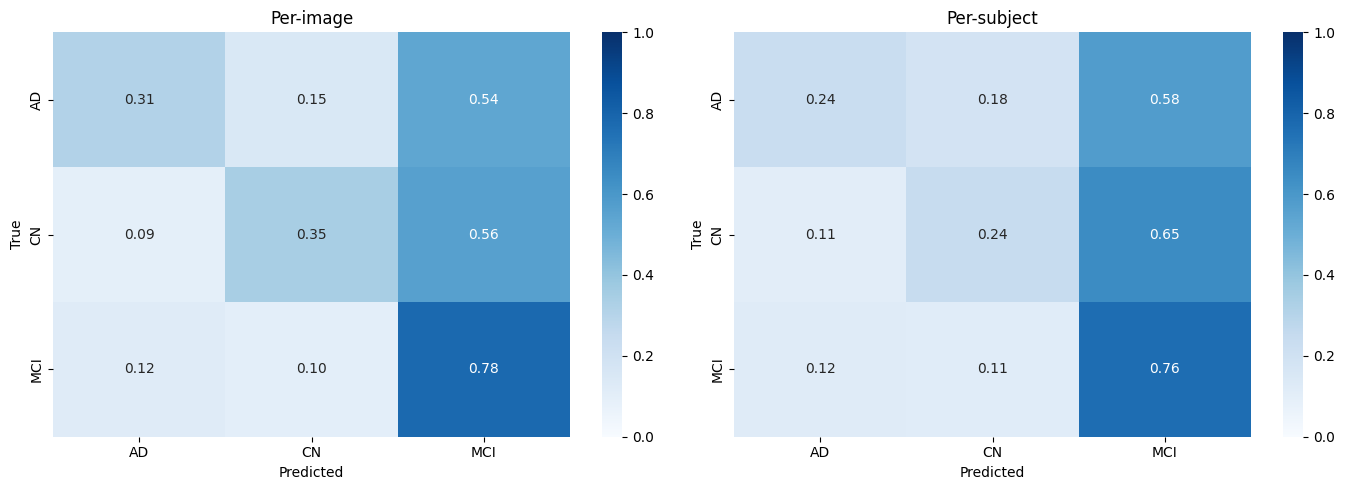

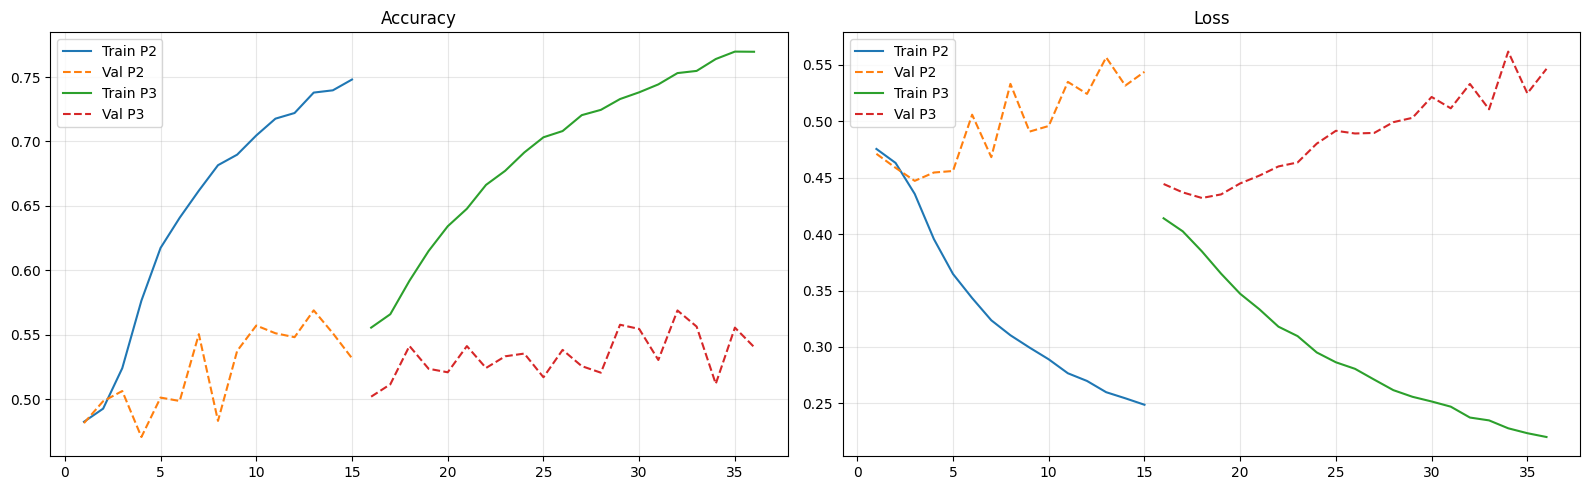

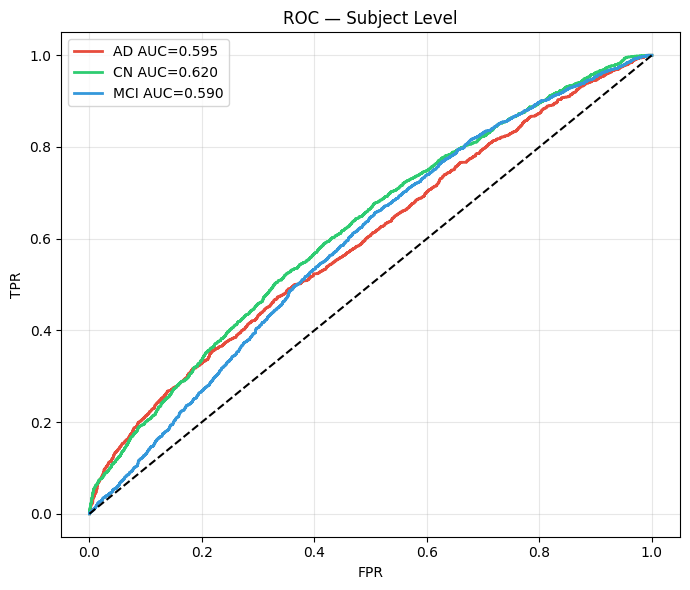

Plots saved.


In [15]:
# Plots
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, cm_data, title in zip(axes,
    [confusion_matrix(y_true_test, y_pred_image),
     confusion_matrix(y_subj_true, y_subj_pred)],
    ['Per-image','Per-subject']):
    cm_n = cm_data.astype(float)/cm_data.sum(axis=1,keepdims=True)
    sns.heatmap(cm_n,annot=True,fmt='.2f',cmap='Blues',ax=ax,
                xticklabels=CLASSES,yticklabels=CLASSES,vmin=0,vmax=1)
    ax.set_title(title); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('./models/confusion_matrices.png',dpi=150); plt.show()

fig, axes = plt.subplots(1,2,figsize=(16,5))
p2n = len(h2.history['accuracy'])
ep2 = range(1, p2n+1)
ep3 = range(p2n+1, p2n+len(h3.history['accuracy'])+1)
axes[0].plot(ep2, h2.history['accuracy'],     label='Train P2')
axes[0].plot(ep2, h2.history['val_accuracy'], label='Val P2', ls='--')
axes[0].plot(ep3, h3.history['accuracy'],     label='Train P3')
axes[0].plot(ep3, h3.history['val_accuracy'], label='Val P3', ls='--')
axes[1].plot(ep2, h2.history['loss'],         label='Train P2')
axes[1].plot(ep2, h2.history['val_loss'],     label='Val P2', ls='--')
axes[1].plot(ep3, h3.history['loss'],         label='Train P3')
axes[1].plot(ep3, h3.history['val_loss'],     label='Val P3', ls='--')
for ax, t in zip(axes,['Accuracy','Loss']):
    ax.set_title(t); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('./models/training_curves.png',dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7,6))
for i,(cls,col) in enumerate(zip(CLASSES,['#e74c3c','#2ecc71','#3498db'])):
    fpr,tpr,_ = roc_curve(y_bin[:,i],y_subj_proba[:,i])
    ax.plot(fpr,tpr,color=col,lw=2,
            label=f'{cls} AUC={roc_auc_score(y_bin[:,i],y_subj_proba[:,i]):.3f}')
ax.plot([0,1],[0,1],'k--'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — Subject Level')
plt.tight_layout(); plt.savefig('./models/roc_curves.png',dpi=150); plt.show()
print('Plots saved.')

In [16]:
print('='*50)
print(f'  Subject Accuracy : {acc*100:.2f}%')
print(f'  Balanced Accuracy: {bal*100:.2f}%')
print(f'  Macro AUC        : {macro_auc:.4f}')
print(f'  AD vs CN AUC     : {bin_auc:.4f}')
print('='*50)
model.save_weights('./models/final_effnetb5.h5')
print('Saved.')

  Subject Accuracy : 49.33%
  Balanced Accuracy: 41.54%
  Macro AUC        : 0.6019
  AD vs CN AUC     : 0.6156
Saved.
